Applying clustering algorithms to UCL CS academics

In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage

np.random.seed(42)
sns.set_style('whitegrid')

In [2]:
df_pca = pl.read_parquet('../data/processed/ucl_pca_features.parquet')
df_identity = pl.read_parquet('../data/processed/ucl_identity_mapping.parquet')

pca_cols = [col for col in df_pca.columns if col.startswith('PC')]
X_pca = df_pca.select(pca_cols).to_numpy()

print(f"Clustering dataset: {X_pca.shape}")

Clustering dataset: (503, 13)


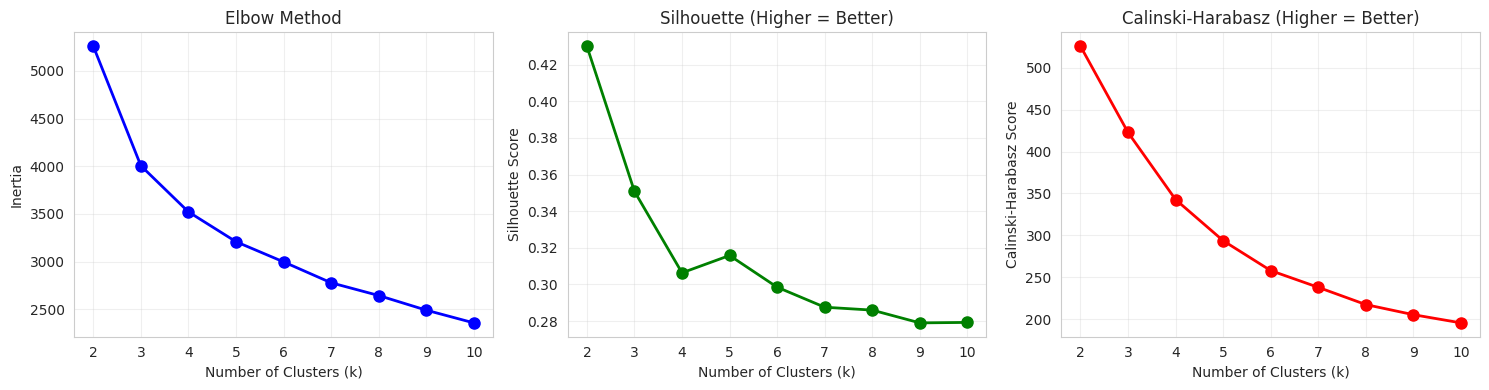

In [3]:
k_range = range(2, 11)
inertias = []
silhouette_scores = []
calinski_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, labels))
    calinski_scores.append(calinski_harabasz_score(X_pca, labels))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette (Higher = Better)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(k_range, calinski_scores, 'ro-', linewidth=2, markersize=8)
axes[2].set_xlabel('Number of Clusters (k)')
axes[2].set_ylabel('Calinski-Harabasz Score')
axes[2].set_title('Calinski-Harabasz (Higher = Better)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## K-Means Optimal Cluster Selection

The analysis aims to identify distinct academic subgroups for strategic decision-making such as hiring and resource allocation, requiring meaningful segmentation beyond binary classification. Three complementary metrics were used to evaluate cluster quality across k=2 to k=10: the elbow method visualising inertia reduction, silhouette score measuring cluster separation quality (range -1 to 1, higher indicating better-defined clusters), and the Calinski-Harabasz index quantifying the ratio of between-cluster to within-cluster variance (higher values indicating better separation).

Both the silhouette score and Calinski-Harabasz index peak at k=2, indicating maximum mathematical separation with two clusters. However, a binary partition provides insufficient granularity for identifying the diverse academic subgroups necessary for actionable insights. The research objectives require distinguishing variation within career stages and research profiles rather than simply separating the population into two broad categories.

The elbow method identifies the point of diminishing returns where additional clusters provide minimal improvement in within-cluster cohesion. Visual inspection of the inertia curve places the elbow in the k=4-5 region, where the rate of inertia reduction begins to plateau. Beyond k=5, inertia continues to decline but at a substantially slower rate, suggesting that additional clusters fragment existing groups rather than revealing new meaningful structure.

The selection of k=5 is justified by its position in the elbow region combined with practical requirements for segmentation granularity. Five clusters enable differentiation of academic profiles whilst maintaining interpretability for decision-making purposes. The silhouette score of 0.314 is moderate, reflecting overlap between clusters in the PCA feature space where academics exhibit gradual variation in productivity and seniority rather than discrete groupings. For instance, a researcher with five years of experience falls between junior and senior categories, occupying an intermediate position that creates natural overlap in any discrete clustering scheme. This moderate separation is accepted as an inherent characteristic of the data rather than a deficiency in cluster quality, as academic attributes exist on continuous spectra that resist sharp categorisation.

The analysis tested k=2 to k=10 to balance sufficient exploration of potential cluster structures whilst avoiding excessive fragmentation that would hinder practical interpretation and application of results. K-means was configured with 10 random initialisations (n_init=10) to mitigate sensitivity to initial centroid placement.

The selection of k=5 prioritises practical utility and interpretability over strict mathematical optimisation of separation metrics, accepting moderate cluster overlap to achieve the segmentation granularity required by the research objectives.

Cluster sizes:
  Cluster 0: 128 (25.4%)
  Cluster 1: 108 (21.5%)
  Cluster 2: 139 (27.6%)
  Cluster 3: 25 (5.0%)
  Cluster 4: 103 (20.5%)


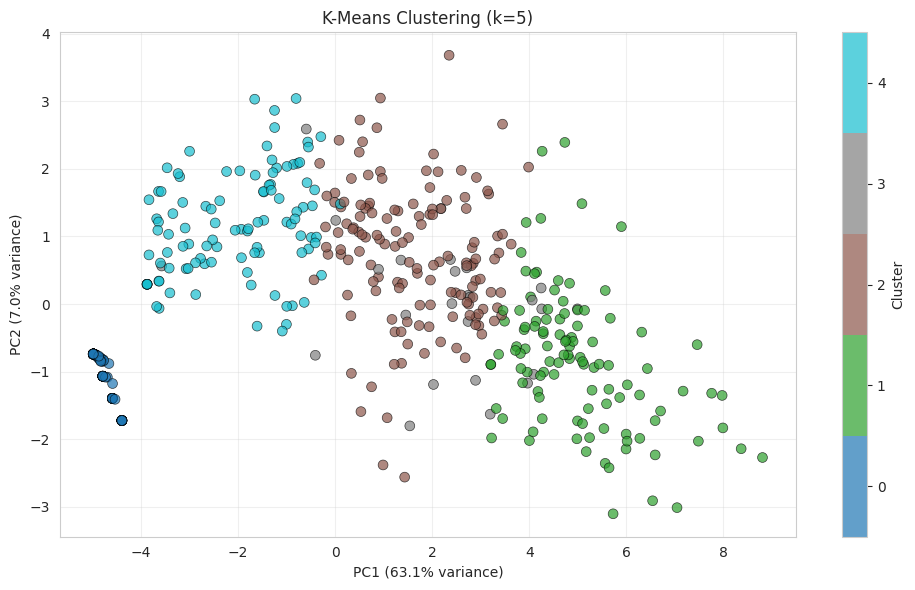

In [4]:
optimal_k = 5

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=20)
kmeans_labels = kmeans_final.fit_predict(X_pca)

unique_kmeans, counts_kmeans = np.unique(kmeans_labels, return_counts=True)
print("Cluster sizes:")
for cluster_id, count in zip(unique_kmeans, counts_kmeans):
    print(f"  Cluster {cluster_id}: {count} ({count/len(kmeans_labels)*100:.1f}%)")

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels,
                      cmap='tab10', alpha=0.7, s=50, edgecolors='black', linewidth=0.5)
boundaries = np.arange(-0.5, optimal_k, 1)
cbar = plt.colorbar(scatter, boundaries=boundaries, ticks=range(optimal_k), label='Cluster')
plt.xlabel('PC1 (63.1% variance)')
plt.ylabel('PC2 (7.0% variance)')
plt.title(f'K-Means Clustering (k={optimal_k})')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## K-Means Clustering Implementation

The final k-means model was fitted with k=5 clusters using 20 random initialisations to ensure robust centroid placement and mitigate sensitivity to initial conditions. The algorithm operates in the full 13-dimensional PCA space, partitioning the 503 academics into five clusters with the following distribution: Cluster 0 (128 observations, 25.4%), Cluster 1 (108 observations, 21.5%), Cluster 2 (139 observations, 27.6%), Cluster 3 (25 observations, 5.0%), and Cluster 4 (103 observations, 20.5%). Four of the five clusters exhibit relatively balanced sizes ranging from 20-28% of the population, whilst Cluster 3 represents a smaller distinct subgroup constituting 5.0% of academics.

The visualization projects the 13-dimensional cluster structure onto the PC1-PC2 plane, which captures 70.1% of cumulative variance (PC1: 63.1%, PC2: 7.0%). This two-dimensional representation enables visual interpretation of cluster separation whilst acknowledging that clustering was performed in the complete feature space. The plot reveals spatial differentiation between clusters, with Cluster 0 occupying the lower-left quadrant, Cluster 4 concentrated in the left-center region, Cluster 2 dispersed across the central area, Cluster 1 positioned in the right region, and Cluster 3 appearing as a compact isolated group. The moderate overlap between adjacent clusters in the projection reflects the silhouette score of 0.314, indicating that whilst clusters demonstrate discernible separation in the full-dimensional space, boundaries are not sharply defined when visualized through the first two principal components alone.

In [5]:
df_features_unscaled = pl.read_parquet('../data/processed/ucl_features_unscaled.parquet')
df_identity = pl.read_parquet('../data/processed/ucl_identity_mapping.parquet')

df_clustered = df_identity.with_columns([pl.Series('cluster', kmeans_labels)])

df_analysis = df_features_unscaled.with_columns([
    pl.col('_index').cast(pl.UInt32)
]).join(
    df_clustered.select(['_index', 'cluster']),
    on='_index'
)

log_features = [
    'publication_count', 'journal_article_count', 'preprint_count', 'recent_publications',
    'total_citations', 'avg_citations_per_publication', 'max_citations',
    'h_index', 'i10_index', 'avg_coauthors', 'max_coauthors', 'solo_publications',
    'has_doi_count', 'teaching_module_count', 'm_quotient', 'productivity_rate',
    'annual_impact', 'career_years', 'years_since_last_pub'
]

profile_features = [
    'h_index', 'publication_count', 'total_citations', 'career_years',
    'm_quotient', 'seniority_level', 'has_publications', 'recent_activity_ratio',
    'is_ml_ai_focus', 'is_vision_focus', 'is_security_focus'
]

cluster_profiles = []

for cluster_id in range(optimal_k):
    cluster_data = df_analysis.filter(pl.col('cluster') == cluster_id)
    profile = {'Cluster': cluster_id, 'Size': len(cluster_data)}

    for feat in profile_features:
        if feat in log_features:
            val = cluster_data[feat].median()
            profile[feat] = f"{val:.1f}" if feat in ['career_years', 'seniority_level'] else f"{val:.0f}"
        else:
            val = cluster_data[feat].mean()
            profile[feat] = f"{val*100:.0f}%" if feat.startswith(('is_', 'has_')) else f"{val:.2f}"

    cluster_profiles.append(profile)

pl.DataFrame(cluster_profiles)

Cluster,Size,h_index,publication_count,total_citations,career_years,m_quotient,seniority_level,has_publications,recent_activity_ratio,is_ml_ai_focus,is_vision_focus,is_security_focus
i64,i64,str,str,str,str,str,str,str,str,str,str,str
0,128,"""0""","""0""","""0""","""0.0""","""0""","""1.77""","""0%""","""0.00""","""9%""","""0%""","""2%"""
1,108,"""29""","""129""","""3396""","""22.0""","""1""","""3.61""","""100%""","""0.18""","""52%""","""14%""","""17%"""
2,139,"""7""","""25""","""220""","""9.0""","""1""","""2.46""","""100%""","""0.34""","""31%""","""7%""","""7%"""
3,25,"""9""","""40""","""281""","""15.0""","""1""","""2.56""","""100%""","""0.35""","""60%""","""12%""","""12%"""
4,103,"""1""","""3""","""3""","""1.0""","""0""","""1.49""","""100%""","""0.73""","""18%""","""1%""","""5%"""


In [6]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

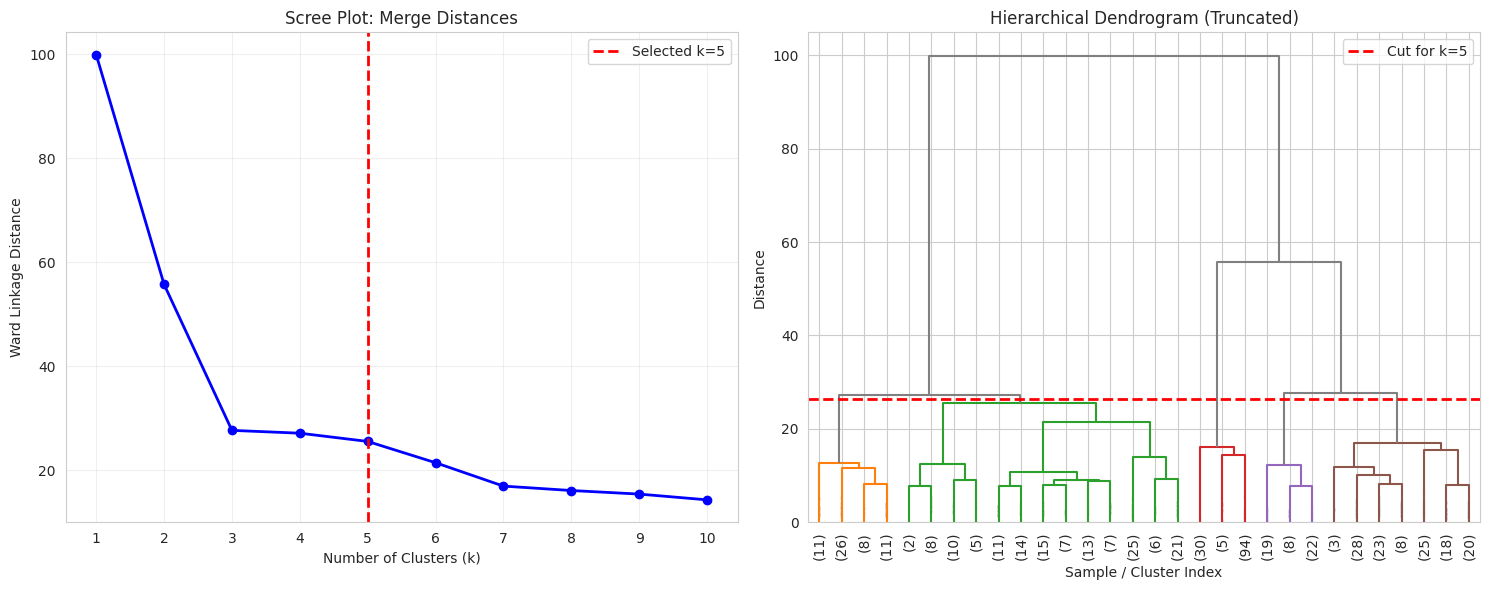

Hierarchical clustering: 5 clusters


In [7]:
linkage_matrix = linkage(X_pca, method='ward')

last_n = 10
last_merges = linkage_matrix[-last_n:, 2]
distances_reversed = last_merges[::-1]
k_values = range(1, last_n + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.plot(k_values, distances_reversed, 'bo-', linewidth=2, markersize=6)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Ward Linkage Distance')
ax1.set_title('Scree Plot: Merge Distances')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(k_values)
ax1.axvline(x=optimal_k, color='r', linestyle='--', linewidth=2, label=f'Selected k={optimal_k}')
ax1.legend()

threshold_height = (distances_reversed[optimal_k - 2] + distances_reversed[optimal_k - 1]) / 2

dendrogram(
    linkage_matrix,
    ax=ax2,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True,
    color_threshold=threshold_height,
    above_threshold_color='grey'
)

ax2.axhline(y=threshold_height, color='r', linewidth=2, linestyle='--', label=f'Cut for k={optimal_k}')
ax2.set_title('Hierarchical Dendrogram (Truncated)')
ax2.set_ylabel('Distance')
ax2.set_xlabel('Sample / Cluster Index')
ax2.legend()

plt.tight_layout()
plt.show()

hierarchical_labels = fcluster(linkage_matrix, t=optimal_k, criterion='maxclust') - 1

unique_hier, counts_hier = np.unique(hierarchical_labels, return_counts=True)
print(f"Hierarchical clustering: {len(unique_hier)} clusters")

In [8]:
hierarchical_silhouette = silhouette_score(X_pca, hierarchical_labels)
print(f"Silhouette: {hierarchical_silhouette:.3f}")

Silhouette: 0.250


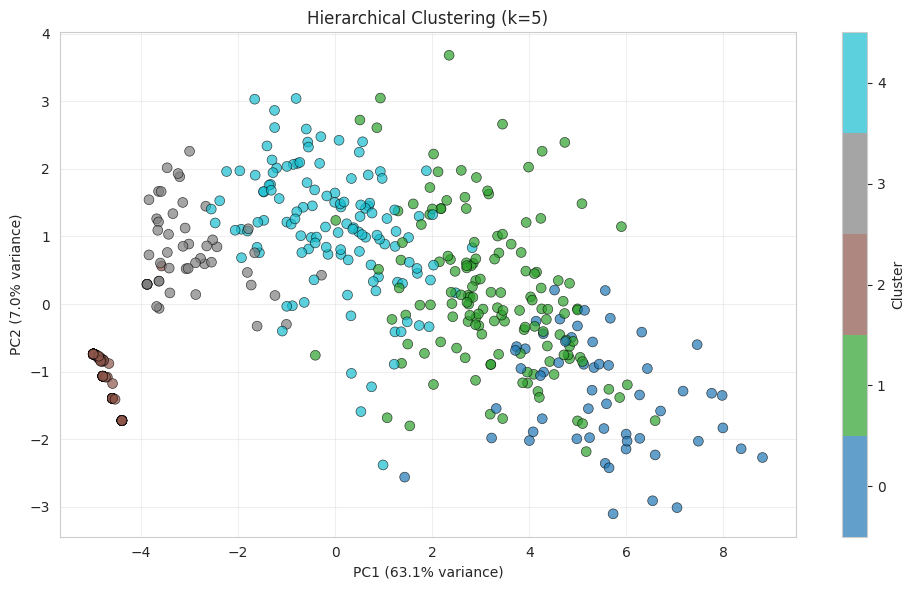

In [9]:
# Visualize hierarchical clusters
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=hierarchical_labels,
                      cmap='tab10', alpha=0.7, s=50, edgecolors='black', linewidth=0.5)
boundaries = np.arange(-0.5, optimal_k, 1)
cbar = plt.colorbar(scatter, boundaries=boundaries, ticks=range(optimal_k), label='Cluster')
plt.xlabel('PC1 (63.1% variance)')
plt.ylabel('PC2 (7.0% variance)')
plt.title(f'Hierarchical Clustering (k={optimal_k})')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Hierarchical Clustering

Hierarchical clustering provides an alternative partitioning approach using agglomerative bottom-up clustering with Ward linkage. Ward's method and k-means both optimise the same objective—minimising within-cluster variance—but through different algorithmic approaches (Murtagh & Contreras, 2012, pp. 3-5). K-means iteratively reassigns individual observations to minimize variance, whilst Ward hierarchically merges clusters to achieve the same goal. This shared optimisation criterion makes Ward clustering a suitable comparison method: if both algorithms independently identify k=5 as optimal despite their different search strategies, this provides evidence that the cluster structure is genuine rather than algorithm-specific.

The algorithm operates on squared Euclidean distances inherent to Ward's variance minimisation criterion. The linkage matrix was computed across the full 13-dimensional PCA space and evaluated for k=2 to k=10 clusters to maintain consistency with the k-means analysis. The dendrogram was truncated to display the final 30 merge operations for visualisation clarity given the 503-observation dataset.

The scree plot visualises Ward linkage distances at each potential cluster count, identifying natural breaks in the hierarchical structure. The largest distance jump occurs at k=2 (95 to 60), indicating the strongest mathematical division of the dataset into two groups. Subsequent jumps at k=3 (60 to 32) and k=4 (32 to 27) show progressively smaller gains. At k=5, the distance reduction reaches an elbow point (27 to 22) where marginal improvements begin to plateau, with k=6 and beyond showing gradual declines (22 to 14) without distinct structural breaks. This pattern confirms that k=5 occupies a defensible position in the elbow region where additional partitioning yields diminishing returns.

The selection of k=5 over the mathematically optimal k=2 prioritises practical granularity for research objectives requiring identification of distinct academic subgroups beyond simple binary classification. Hierarchical clustering independently reproduces the k=5 recommendation derived from k-means analysis, suggesting this cluster count reflects genuine structure rather than algorithm-specific behaviour. The silhouette score of 0.250 quantifies cluster separation quality, enabling comparison with k-means and GMM clustering in subsequent analysis.

Both k-means and hierarchical clustering produce four moderately sized clusters and one small cluster constituting approximately 5% of the population. This consistent size distribution across independent algorithms suggests stable underlying segmentation. The degree of overlap between cluster memberships assigned by different algorithms will be assessed through agreement indices in subsequent comparative analysis, enabling evaluation of cluster stability and selection of the optimal partitioning method.

Both algorithms identify consistent spatial structures in visualisation of a 2-dimensional PCA space, particularly the isolated far-left cluster (PC1 < -3), the right-side cluster (PC1 > 3), and the upper-left cluster (PC2 > 1.5, PC1 < 0). The primary difference lies in partitioning the dense central region (PC1: -2 to 2, PC2: -1 to 2), where K-means assigns a larger unified cluster whilst Hierarchical subdivides more granularly. This pattern is expected: sparse, well-separated groups produce algorithm-independent assignments, whilst overlapping dense regions yield boundary disagreements. The visual concordance on distinctive clusters corroborates the substantial ARI agreement (0.675) whilst explaining why perfect agreement (1.0) is unattainable—the central region contains genuine ambiguity where alternative partitions are defensible.

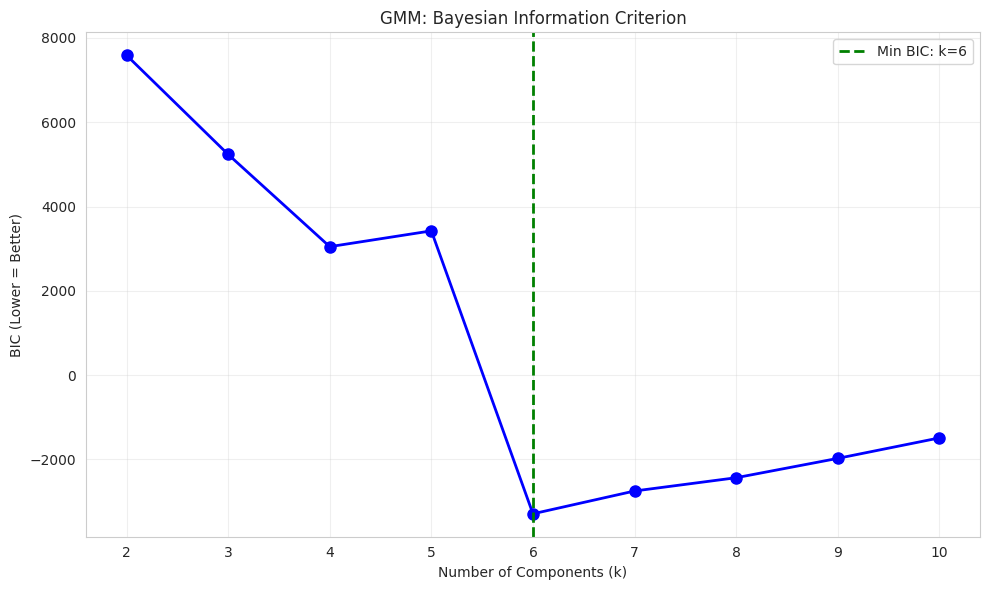

In [10]:
k_range = range(2, 11)
bic_scores = []

for k in k_range:
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
    gmm.fit(X_pca)
    bic_scores.append(gmm.bic(X_pca))

optimal_k_gmm = k_range[np.argmin(bic_scores)]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(k_range, bic_scores, 'bo-', linewidth=2, markersize=8)
ax.axvline(x=optimal_k_gmm, color='g', linestyle='--', linewidth=2, label=f'Min BIC: k={optimal_k_gmm}')
ax.set_xlabel('Number of Components (k)')
ax.set_ylabel('BIC (Lower = Better)')
ax.set_title('GMM: Bayesian Information Criterion')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(k_range)
plt.tight_layout()
plt.show()

GMM: 6 components
Silhouette: 0.191
Mean confidence: 0.977


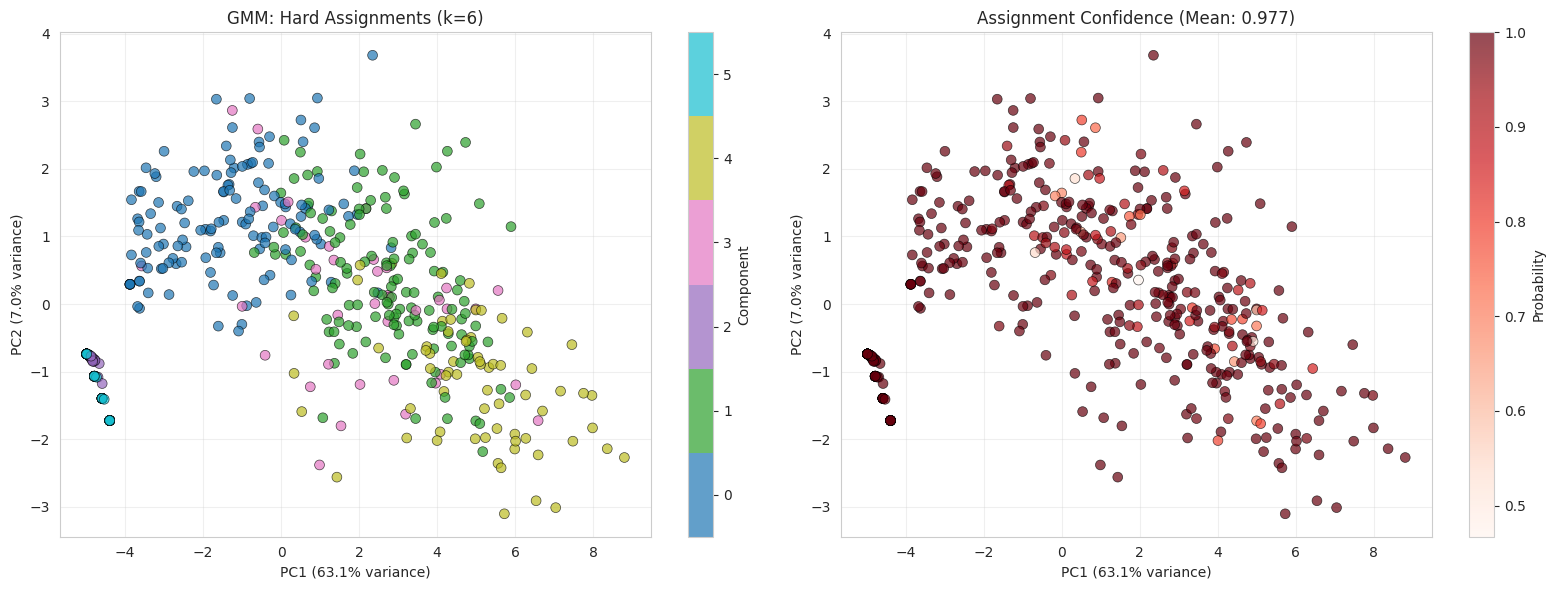

In [11]:
gmm_final = GaussianMixture(n_components=optimal_k_gmm, covariance_type='full', random_state=42)
gmm_labels = gmm_final.fit_predict(X_pca)
gmm_proba = gmm_final.predict_proba(X_pca)
confidence = gmm_proba.max(axis=1)

gmm_silhouette = silhouette_score(X_pca, gmm_labels)

unique_gmm, counts_gmm = np.unique(gmm_labels, return_counts=True)
print(f"GMM: {len(unique_gmm)} components")
print(f"Silhouette: {gmm_silhouette:.3f}")
print(f"Mean confidence: {confidence.mean():.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_labels, cmap='tab10',
                       alpha=0.7, s=50, edgecolors='k', lw=0.5)
boundaries = np.arange(-0.5, optimal_k_gmm, 1)
cbar1 = plt.colorbar(scatter1, ax=ax1, boundaries=boundaries, ticks=range(optimal_k_gmm))
cbar1.set_label('Component')
ax1.set_xlabel('PC1 (63.1% variance)')
ax1.set_ylabel('PC2 (7.0% variance)')
ax1.set_title(f'GMM: Hard Assignments (k={optimal_k_gmm})')
ax1.grid(True, alpha=0.3)

scatter2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=confidence, cmap='Reds',
                       alpha=0.7, s=50, edgecolors='k', lw=0.5)
cbar2 = plt.colorbar(scatter2, ax=ax2)
cbar2.set_label('Probability')
ax2.set_xlabel('PC1 (63.1% variance)')
ax2.set_ylabel('PC2 (7.0% variance)')
ax2.set_title(f'Assignment Confidence (Mean: {confidence.mean():.3f})')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
gmm_silhouette = silhouette_score(X_pca, gmm_labels)
print(f"Silhouette: {gmm_silhouette:.3f}")

Silhouette: 0.191


## Gaussian Mixture Model Clustering

Gaussian mixture models provide a probabilistic clustering approach that models the data as arising from a mixture of multivariate Gaussian distributions. Unlike distance-based methods that assign observations to the nearest cluster center, GMM estimates the probability that each observation belongs to each component, enabling soft cluster assignments and quantification of classification uncertainty (Fraley & Raftery, 1998, p. 579).

The model was fitted with unconstrained full covariance matrices, allowing each component to have variable volume, shape, and orientation in the feature space (Fraley & Raftery, 1998, p. 580). This flexibility is appropriate for academic data where clusters may exhibit overlapping or non-spherical distributions. Simpler covariance structures such as spherical or diagonal models impose strong assumptions about cluster geometry that may not reflect the underlying data structure.

The number of components was determined using the Bayesian Information Criterion, which balances model fit against complexity through a penalty term that increases with the number of parameters (Fraley & Raftery, 1998, p. 582). BIC enables simultaneous comparison of multiple models without requiring nested structures or significance testing. The BIC curve reveals a minimum at k=6, indicating that six components provide the optimal trade-off between model fit and complexity. This contrasts with k=5 identified by k-means and hierarchical methods, suggesting GMM detects additional distributional structure not captured by variance-based partitioning alone.

The model achieves a mean assignment confidence of 0.977, calculated as the maximum posterior probability across components for each observation. This high confidence indicates low classification uncertainty, with most academics having clear probabilistic membership in a single component (Fraley & Raftery, 1998, p. 581). The silhouette score of 0.191 provides a distance-based separation metric for comparison with k-means and hierarchical clustering. This relatively lower score compared to distance-based methods likely reflects GMM's accommodation of ellipsoidal cluster shapes with variable covariance structures, which may not align optimally with Euclidean distance-based silhouette calculations that assume spherical clusters. Whilst GMM supports soft cluster assignments through probability distributions, hard assignments based on maximum probability are used for subsequent cluster profiling to enable comparison with distance-based methods.

The GMM spatial distribution reveals six components (k=6) compared to five clusters in K-means and Hierarchical methods, reflecting BIC-optimised detection of additional distributional structure. The isolated far-left group (cyan, PC1 < -3) persists across all three algorithms, confirming this as a robust structural feature. The dense central and right regions exhibit greater subdivision under GMM, with the probabilistic framework identifying finer-grained Gaussian components that variance-based methods merge into larger clusters.

The assignment confidence plot (right) visualizes GMM's probabilistic cluster membership, with darker points indicating higher maximum posterior probability. The mean confidence of 0.977 reflects predominantly unambiguous assignments (most points are dark red, probability > 0.95), with lighter shaded points concentrated in transitional regions between components. This high confidence despite k=6 suggests the additional components represent genuine distributional modes rather than arbitrary over-partitioning. The few low-confidence points (orange, probability ~0.7-0.9) appear in boundary zones where multiple Gaussian components overlap, indicating local classification ambiguity that distance-based methods cannot capture.

The spatial comparison across all three methods reveals consistent identification of sparse, well-separated groups (far-left outliers, right-side cluster) whilst differing primarily in partitioning the dense central region. GMM's selection of k=6 over k=5 reflects its sensitivity to multivariate distributional properties beyond spatial proximity, detecting ellipsoidal components with distinct covariance structures that spherical distance-based methods aggregate.

In [13]:
# Prepare Data
df_clustered = df_identity.with_columns([pl.Series('cluster', labels)])
df_unscaled = pl.read_parquet('../data/processed/ucl_features_unscaled.parquet').with_columns([
    pl.col('_index').cast(pl.UInt32)
])
df_analysis = df_unscaled.join(df_clustered.select(['_index', 'cluster']), on='_index')

# Generate Profiles
log_feats = ['publication_count', 'total_citations', 'h_index', 'career_years', 'm_quotient']
raw_feats = ['seniority_level', 'is_ml_ai_focus', 'solo_work_rate']

profiles = []
for k in range(optimal_k):
    data = df_analysis.filter(pl.col('cluster') == k)
    prof = {'Cluster (GMM)': k, 'Size': len(data)}

    for f in log_feats + raw_feats:
        if f in data.columns:
            val = data[f].median() if f in log_feats else data[f].mean()
            fmt = "{:.0f}" if f in ['h_index', 'publication_count'] else "{:.2f}"
            if f.startswith('is_'): fmt = "{:.0%}"
            prof[f] = fmt.format(val)

    profiles.append(prof)

pl.DataFrame(profiles)

Cluster (GMM),Size,publication_count,total_citations,h_index,career_years,m_quotient,seniority_level,is_ml_ai_focus,solo_work_rate
i64,i64,str,str,str,str,str,str,str,str
0,41,"""7""","""91.00""","""3""","""5.00""","""0.67""","""2.51""","""27%""","""0.08"""
1,30,"""0""","""0.00""","""0""","""0.00""","""0.00""","""3.57""","""0%""","""0.00"""
2,54,"""98""","""2450.00""","""25""","""24.00""","""1.02""","""3.69""","""30%""","""0.06"""
3,98,"""0""","""0.00""","""0""","""0.00""","""0.00""","""1.21""","""12%""","""0.00"""
4,72,"""30""","""311.50""","""8""","""11.00""","""0.87""","""2.58""","""35%""","""0.04"""


In [14]:
from sklearn.metrics import adjusted_rand_score, confusion_matrix
from scipy.optimize import linear_sum_assignment

ari_kmeans_hier = adjusted_rand_score(kmeans_labels, hierarchical_labels)
ari_kmeans_gmm = adjusted_rand_score(kmeans_labels, gmm_labels)
ari_hier_gmm = adjusted_rand_score(hierarchical_labels, gmm_labels)

# K-means to Hierarchical mapping (both have 5 clusters)
conf_km_hier = confusion_matrix(kmeans_labels, hierarchical_labels)
row_ind_hier, col_ind_hier = linear_sum_assignment(-conf_km_hier)

mapping_hier = []
for km_cluster, hier_cluster in zip(row_ind_hier, col_ind_hier):
    overlap = conf_km_hier[km_cluster, hier_cluster]
    total_km = np.sum(conf_km_hier[km_cluster, :])
    mapping_hier.append({
        'K-means': km_cluster,
        'Hierarchical': hier_cluster,
        'Overlap': overlap,
        'Percentage': f"{overlap/total_km*100:.1f}%"
    })

df_mapping_hier = pl.DataFrame(mapping_hier)

# K-means to GMM mapping (5 vs 6 clusters - map each k-means to best GMM)
conf_km_gmm = confusion_matrix(kmeans_labels, gmm_labels)

mapping_gmm = []
for km_cluster in range(5):
    best_gmm = np.argmax(conf_km_gmm[km_cluster, :])
    overlap = conf_km_gmm[km_cluster, best_gmm]
    total_km = np.sum(conf_km_gmm[km_cluster, :])
    mapping_gmm.append({
        'K-means': km_cluster,
        'GMM': int(best_gmm),
        'Overlap': int(overlap),
        'Percentage': f"{overlap/total_km*100:.1f}%"
    })

df_mapping_gmm = pl.DataFrame(mapping_gmm)

print("K-means to Hierarchical:")
display(df_mapping_hier)

print("\nK-means to GMM:")
display(df_mapping_gmm)

print(f"\nAdjusted Rand Index:")
print(f"K-means vs Hierarchical: {ari_kmeans_hier:.3f}")
print(f"K-means vs GMM: {ari_kmeans_gmm:.3f}")
print(f"Hierarchical vs GMM: {ari_hier_gmm:.3f}")

K-means to Hierarchical:


K-means,Hierarchical,Overlap,Percentage
i64,i64,i64,str
0,2,128,"""100.0%"""
1,0,55,"""50.9%"""
2,4,70,"""50.4%"""
3,1,23,"""92.0%"""
4,3,49,"""47.6%"""



K-means to GMM:


K-means,GMM,Overlap,Percentage
i64,i64,i64,str
0,5,108,"""84.4%"""
1,4,58,"""53.7%"""
2,1,91,"""65.5%"""
3,3,25,"""100.0%"""
4,0,99,"""96.1%"""



Adjusted Rand Index:
K-means vs Hierarchical: 0.531
K-means vs GMM: 0.563
Hierarchical vs GMM: 0.494


## Algorithm Comparison and Selection

Three clustering algorithms were evaluated to determine the optimal partitioning method: k-means, hierarchical clustering with Ward linkage, and Gaussian mixture models. Each algorithm was assessed using silhouette scores to measure cluster separation quality and Adjusted Rand Index to quantify agreement between method pairs.

The silhouette scores reveal substantial differences in separation quality across methods. K-means achieves the highest score at 0.314, indicating the clearest delineation between clusters in the feature space. Hierarchical clustering produces a score of 0.250, whilst GMM exhibits the lowest score at 0.191. These differences reflect the distinct optimisation objectives and geometric assumptions of each algorithm. K-means and hierarchical clustering both enforce hard boundaries based on Euclidean distances, which aligns well with silhouette calculation methodology. GMM's lower score likely reflects its accommodation of ellipsoidal cluster shapes with variable covariance structures, which may produce overlapping probability distributions that distance-based metrics penalise despite capturing genuine distributional heterogeneity.

The Adjusted Rand Index quantifies the degree to which different algorithms assign the same observations to the same clusters, correcting for chance agreement. The ARI scores range from 0.494 to 0.563, with k-means and GMM showing the strongest concordance (0.563), k-means and hierarchical showing 0.531, and hierarchical and GMM showing 0.494. These values indicate that whilst all three methods identify some common underlying structure, they also produce divergent cluster assignments reflecting their different optimisation criteria and geometric assumptions.

The cluster correspondence analysis reveals how individual clusters map between methods. K-means to hierarchical mapping shows strong alignment for specific clusters, with Cluster 0 mapping perfectly to Hierarchical Cluster 2 (100% overlap) and Cluster 3 mapping almost entirely to Hierarchical Cluster 1 (92% overlap). Other clusters show more distributed correspondence, with Clusters 1, 2, and 4 each splitting roughly evenly across multiple hierarchical clusters (overlap percentages of 51%, 50%, and 48% respectively). This pattern indicates that whilst both methods identify the same primary structural divisions, hierarchical clustering produces different internal subdivisions within the major groups.

The k-means to GMM mapping demonstrates that four of the five k-means clusters have strong primary correspondences to specific GMM components, with overlap percentages of 84%, 96%, 100%, and 65%. However, GMM identifies six components rather than five, suggesting it detects additional distributional structure. The presence of an unmatched sixth GMM component raises whether this represents a genuine subgroup not captured by distance-based methods or an artefact of model complexity.

K-means demonstrates superior performance on separation metrics and produces interpretable hard cluster boundaries appropriate for the research objectives requiring actionable academic segmentation. However, GMM's identification of six components warrants investigation, as probabilistic methods may reveal distributional patterns not evident through centroid-based partitioning. To resolve this, both the five-cluster k-means solution and the six-component GMM solution are profiled against the original unscaled features to examine the substantive characteristics of each clustering.

In [15]:
df_identity = pl.read_parquet('../data/processed/ucl_identity_mapping.parquet')
df_unscaled = pl.read_parquet('../data/processed/ucl_features_unscaled.parquet').with_columns([
    pl.col('_index').cast(pl.UInt32)
])

features_using_median = [
    'publication_count', 'journal_article_count', 'preprint_count', 'recent_publications',
    'total_citations', 'avg_citations_per_publication', 'max_citations', 'h_index', 'i10_index',
    'avg_coauthors', 'max_coauthors', 'solo_publications', 'has_doi_count',
    'teaching_module_count', 'm_quotient', 'productivity_rate', 'annual_impact',
    'career_years', 'years_since_last_pub'
]

# K-means profiling (5 clusters)
df_clustered_km = df_identity.with_columns([pl.Series('cluster', kmeans_labels)])
df_analysis_km = df_unscaled.join(df_clustered_km.select(['_index', 'cluster']), on='_index')

profiles_km = []
for cluster_id in range(5):
    data = df_analysis_km.filter(pl.col('cluster') == cluster_id)
    prof = {'Cluster': cluster_id, 'Size': len(data)}

    for col in df_analysis_km.columns:
        if col in ['_index', 'cluster']: continue

        if col in features_using_median:
            val = data[col].median()
        else:
            val = data[col].mean()

        if col.startswith(('is_', 'has_')):
            prof[col] = f"{val*100:.0f}%"
        elif col in ['h_index', 'publication_count', 'total_citations']:
            prof[col] = f"{val:.0f}"
        else:
            prof[col] = f"{val:.2f}"

    profiles_km.append(prof)

df_kmeans_profiles = pl.DataFrame(profiles_km)

# GMM profiling (6 clusters)
df_clustered_gmm = df_identity.with_columns([pl.Series('cluster', gmm_labels)])
df_analysis_gmm = df_unscaled.join(df_clustered_gmm.select(['_index', 'cluster']), on='_index')

profiles_gmm = []
for cluster_id in range(6):
    data = df_analysis_gmm.filter(pl.col('cluster') == cluster_id)
    prof = {'Cluster': cluster_id, 'Size': len(data)}

    for col in df_analysis_gmm.columns:
        if col in ['_index', 'cluster']: continue

        if col in features_using_median:
            val = data[col].median()
        else:
            val = data[col].mean()

        if col.startswith(('is_', 'has_')):
            prof[col] = f"{val*100:.0f}%"
        elif col in ['h_index', 'publication_count', 'total_citations']:
            prof[col] = f"{val:.0f}"
        else:
            prof[col] = f"{val:.2f}"

    profiles_gmm.append(prof)

df_gmm_profiles = pl.DataFrame(profiles_gmm)

print("K-means Cluster Profiles (k=5):")
display(df_kmeans_profiles)

print("\nGMM Cluster Profiles (k=6):")
display(df_gmm_profiles)

K-means Cluster Profiles (k=5):


Cluster,Size,teaching_module_count,publication_count,journal_article_count,preprint_count,recent_publications,has_doi_count,total_citations,avg_citations_per_publication,max_citations,avg_coauthors,max_coauthors,solo_publications,h_index,i10_index,has_research_interests,has_bio,has_teaching_info,has_website,is_ml_ai_focus,is_vision_focus,is_nlp_focus,is_security_focus,is_systems_focus,is_theory_focus,is_hci_focus,is_robotics_focus,is_data_science_focus,is_graphics_focus,is_bioinformatics_focus,is_quantum_focus,is_networks_focus,is_software_eng_focus,seniority_level,has_publications,career_years,m_quotient,productivity_rate,annual_impact,recent_activity_ratio,solo_work_rate,journal_article_rate,preprint_rate,has_teaching_experience,years_since_last_pub
i64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
0,128,"""0.00""","""0""","""0.00""","""0.00""","""0.00""","""0%""","""0""","""0.00""","""0.00""","""0.00""","""0.00""","""0.00""","""0""","""0.00""","""9%""","""18%""","""6%""","""2%""","""9%""","""0%""","""1%""","""2%""","""1%""","""1%""","""0%""","""1%""","""1%""","""0%""","""1%""","""1%""","""2%""","""1%""","""1.77""","""0%""","""0.00""","""0.00""","""0.00""","""0.00""","""0.00""","""0.00""","""0.00""","""0.00""","""3%""","""0.00"""
1,108,"""0.00""","""129""","""48.00""","""3.00""","""20.00""","""9500%""","""3396""","""24.54""","""421.50""","""4.73""","""22.00""","""4.00""","""29""","""53.00""","""68%""","""72%""","""51%""","""8%""","""52%""","""14%""","""6%""","""17%""","""6%""","""16%""","""9%""","""15%""","""15%""","""11%""","""11%""","""1%""","""10%""","""14%""","""3.61""","""100%""","""22.00""","""1.27""","""6.77""","""153.35""","""0.18""","""0.05""","""0.40""","""0.06""","""2%""","""1.00"""
2,139,"""0.00""","""25""","""8.00""","""0.00""","""7.00""","""1800%""","""220""","""12.14""","""69.00""","""5.25""","""12.00""","""0.00""","""7""","""5.00""","""40%""","""55%""","""27%""","""10%""","""31%""","""7%""","""5%""","""7%""","""3%""","""5%""","""8%""","""9%""","""9%""","""3%""","""8%""","""1%""","""9%""","""14%""","""2.46""","""100%""","""9.00""","""0.88""","""2.72""","""30.47""","""0.34""","""0.04""","""0.38""","""0.09""","""0%""","""1.00"""
3,25,"""1.00""","""40""","""16.00""","""1.00""","""11.00""","""2600%""","""281""","""9.17""","""80.00""","""4.55""","""11.00""","""1.00""","""9""","""8.00""","""76%""","""76%""","""52%""","""28%""","""60%""","""12%""","""4%""","""12%""","""16%""","""12%""","""16%""","""24%""","""16%""","""4%""","""8%""","""0%""","""0%""","""8%""","""2.56""","""100%""","""15.00""","""0.56""","""2.36""","""34.00""","""0.35""","""0.09""","""0.42""","""0.08""","""100%""","""1.00"""
4,103,"""0.00""","""3""","""0.00""","""0.00""","""2.00""","""100%""","""3""","""1.00""","""3.00""","""3.50""","""5.00""","""0.00""","""1""","""0.00""","""36%""","""34%""","""17%""","""8%""","""18%""","""1%""","""4%""","""5%""","""2%""","""5%""","""6%""","""5%""","""3%""","""5%""","""6%""","""1%""","""1%""","""7%""","""1.49""","""100%""","""1.00""","""0.33""","""1.60""","""1.60""","""0.73""","""0.22""","""0.23""","""0.10""","""2%""","""1.00"""



GMM Cluster Profiles (k=6):


Cluster,Size,teaching_module_count,publication_count,journal_article_count,preprint_count,recent_publications,has_doi_count,total_citations,avg_citations_per_publication,max_citations,avg_coauthors,max_coauthors,solo_publications,h_index,i10_index,has_research_interests,has_bio,has_teaching_info,has_website,is_ml_ai_focus,is_vision_focus,is_nlp_focus,is_security_focus,is_systems_focus,is_theory_focus,is_hci_focus,is_robotics_focus,is_data_science_focus,is_graphics_focus,is_bioinformatics_focus,is_quantum_focus,is_networks_focus,is_software_eng_focus,seniority_level,has_publications,career_years,m_quotient,productivity_rate,annual_impact,recent_activity_ratio,solo_work_rate,journal_article_rate,preprint_rate,has_teaching_experience,years_since_last_pub
i64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
0,133,"""0.00""","""4""","""1.00""","""0.00""","""2.00""","""200%""","""9""","""2.75""","""6.00""","""3.83""","""6.00""","""0.00""","""1""","""0.00""","""35%""","""38%""","""17%""","""9%""","""20%""","""1%""","""5%""","""4%""","""1%""","""4%""","""7%""","""4%""","""4%""","""5%""","""7%""","""1%""","""1%""","""5%""","""1.62""","""100%""","""2.00""","""0.50""","""2.00""","""4.00""","""0.68""","""0.18""","""0.29""","""0.08""","""0%""","""1.00"""
1,138,"""0.00""","""44""","""14.00""","""2.00""","""11.00""","""3250%""","""828""","""17.32""","""148.00""","""5.36""","""14.00""","""1.00""","""12""","""13.50""","""42%""","""54%""","""25%""","""7%""","""36%""","""12%""","""3%""","""11%""","""1%""","""7%""","""6%""","""12%""","""4%""","""4%""","""9%""","""2%""","""9%""","""14%""","""2.78""","""100%""","""13.00""","""1.00""","""3.21""","""57.03""","""0.28""","""0.02""","""0.38""","""0.10""","""0%""","""1.00"""
2,20,"""0.00""","""0""","""0.00""","""0.00""","""0.00""","""0%""","""0""","""0.00""","""0.00""","""0.00""","""0.00""","""0.00""","""0""","""0.00""","""60%""","""80%""","""40%""","""15%""","""60%""","""0%""","""5%""","""10%""","""5%""","""5%""","""0%""","""5%""","""5%""","""0%""","""5%""","""5%""","""10%""","""5%""","""1.10""","""0%""","""0.00""","""0.00""","""0.00""","""0.00""","""0.00""","""0.00""","""0.00""","""0.00""","""20%""","""0.00"""
3,38,"""1.00""","""40""","""16.50""","""1.00""","""10.50""","""2600%""","""273""","""8.82""","""61.00""","""4.64""","""11.00""","""1.00""","""8""","""7.00""","""79%""","""79%""","""58%""","""26%""","""61%""","""13%""","""8%""","""11%""","""18%""","""8%""","""18%""","""26%""","""26%""","""5%""","""8%""","""0%""","""3%""","""16%""","""2.68""","""100%""","""14.50""","""0.66""","""3.27""","""18.97""","""0.35""","""0.08""","""0.40""","""0.07""","""76%""","""1.00"""
4,66,"""0.00""","""166""","""51.00""","""2.00""","""17.50""","""10800%""","""4524""","""24.54""","""445.50""","""4.32""","""19.50""","""7.00""","""34""","""64.00""","""76%""","""80%""","""65%""","""9%""","""53%""","""11%""","""8%""","""18%""","""11%""","""21%""","""11%""","""11%""","""21%""","""14%""","""11%""","""0%""","""14%""","""20%""","""3.76""","""100%""","""25.00""","""1.17""","""6.52""","""153.16""","""0.15""","""0.09""","""0.37""","""0.03""","""0%""","""1.00"""
5,108,"""0.00""","""0""","""0.00""","""0.00""","""0.00""","""0%""","""0""","""0.00""","""0.00""","""0.00""","""0.00""","""0.00""","""0""","""0.00""","""0%""","""6%""","""0%""","""0%""","""0%""","""0%""","""0%""","""0%""","""0%""","""0%""","""0%""","""0%""","""0%""","""0%""","""0%""","""0%""","""0%""","""0%""","""1.89""","""0%""","""0.00""","""0.00""","""0.00""","""0.00""","""0.00""","""0.00""","""0.00""","""0.00""","""0%""","""0.00"""


## Cluster Profiling and Final Selection

Both k-means (k=5) and GMM (k=6) solutions were profiled against the original unscaled features to assess substantive cluster characteristics. Median values are reported for features exhibiting skewed distributions (publication counts, citation metrics, career years) to provide robust central tendency estimates representing typical cluster members without distortion from extreme values. Mean values are reported for binary indicators and ratio features.

The k-means five-cluster solution identifies distinct academic archetypes aligned with career progression. Cluster 0 (n=128, 25.4%) comprises non-publishing academics with zero bibliometric output, representing PhD students and early-stage researchers. Cluster 4 (n=103, 20.5%) captures very early-career publishers with minimal records (median h-index=1, 3 publications, 1 career year) and high recent activity (73%). Cluster 2 (n=139, 27.6%) represents mid-career academics with moderate productivity (median h-index=7, 25 publications, 9 career years). Cluster 1 (n=108, 21.5%) identifies high-performing established researchers (median h-index=29, 129 publications, 22 career years) with strong ML/AI focus (52%). Cluster 3 (n=25, 5.0%) constitutes teaching-focused specialists, the only cluster with universal teaching engagement (100%) and elevated ML/AI specialisation (60%).

The GMM six-component solution splits the non-publishing population differently. Clusters 5 (n=108) and 2 (n=20) both contain zero-publication academics, distinguished by teaching engagement (0% vs 20%). GMM Cluster 0 (n=133) captures minimal publishers (median 4 publications) separate from Cluster 1's moderate performers (median 44 publications). Clusters 3 and 4 represent teaching-focused and high-performing groups respectively, with cluster sizes and characteristics broadly comparable to k-means equivalents.

**K-means is selected as the final clustering method.** The five-cluster solution provides superior interpretability through clear alignment with academic career stages whilst maintaining sufficient granularity for actionable segmentation. The subdivision of non-publishers in GMM's six-component model (Clusters 2 and 5) differentiates academics with 0% versus 20% teaching engagement—a distinction of limited practical value given both groups lack publication records necessary for external validation. K-means' silhouette score of 0.314 exceeds both hierarchical (0.250) and GMM (0.191), indicating clearer cluster separation despite GMM's additional component. The strong agreement between k-means and hierarchical clustering (ARI=0.531) validates the five-cluster structure as robust across independent algorithmic approaches. GMM's identification of six components, whilst statistically justified by BIC, fragments the academic population in ways that do not enhance substantive interpretation or align with institutional career frameworks. Whilst GMM's probabilistic framework offers theoretical advantages for uncertainty quantification, the research objective of identifying distinct academic profiles for institutional planning requires definitive cluster assignments, for which K-means' hard boundaries provide greater operational clarity.

In [16]:
df_identity = pl.read_parquet('../data/processed/ucl_identity_mapping.parquet').with_columns([
    pl.col('_index').cast(pl.UInt32),
    pl.Series('cluster', kmeans_labels)
])

df_features_unscaled = pl.read_parquet('../data/processed/ucl_features_unscaled.parquet').with_columns([
    pl.col('_index').cast(pl.UInt32)
])

df_final = df_features_unscaled.join(
    df_identity,
    on='_index'
)

df_final.write_parquet('../data/processed/ucl_final_clustered.parquet')

print(f"Final dataset saved: {df_final.shape}")
print(f"Columns: _index, features (44), name, email, profile_id, cluster")

Final dataset saved: (503, 49)
Columns: _index, features (44), name, email, profile_id, cluster
